In [1]:
from scipy.optimize import curve_fit
import matplotlib.pylab as plt
import numpy as np

In [2]:
def func(x, a, b):
    return a * x + b 

x_data = [5.25,10.5,15.75,21.0]
A_2f = [0.0155, 0.0262, 0.0472, 0.0596]
H_2f = [0.0112, 0.0201, 0.0297, 0.0394]
y_spread = [0.000231, 0.000514, 0.000471, 0.00131]

# averages and dispersion of data
#y_means = np.array(y_data).mean(axis = 1)
#y_spread = np.array(y_data).std(axis = 1)

best_fit_ab, covar = curve_fit(func, x_data, A_2f,
                               sigma = y_spread,
                               absolute_sigma = True)
sigma_ab = np.sqrt(np.diagonal(covar))

best_fit_ab2, covar2 = curve_fit(func, x_data, H_2f,
                               sigma = y_spread,
                               absolute_sigma = True)
sigma_ab2 = np.sqrt(np.diagonal(covar2))

In [3]:
from uncertainties import ufloat
a = ufloat(best_fit_ab[0], sigma_ab[0])
b = ufloat(best_fit_ab[1], sigma_ab[1])
text_res = "Best-fit (linear) parameters: \na = {}\nb = {}".format(a, b)
print(text_res)

a2 = ufloat(best_fit_ab2[0], sigma_ab2[0])
b2 = ufloat(best_fit_ab2[1], sigma_ab2[1])
text_res2 = "Best-fit (linear) parameters: \na = {}\nb = {}".format(a2, b2)
print(text_res2)

Best-fit (linear) parameters: 
a = 0.00288+/-0.00004
b = -0.0000+/-0.0004
Best-fit (linear) parameters: 
a = 0.00176+/-0.00004
b = 0.0019+/-0.0004


In [4]:
# plotting the unaveraged data
#flier_kwargs = dict(marker = 'o', markerfacecolor = 'silver',
#                    markersize = 3, alpha=0.7)
#line_kwargs = dict(color = 'k', linewidth = 1)

#bp = plt.boxplot(y_data, positions = x_data,
#                 capprops = line_kwargs,
#                 boxprops = line_kwargs,
#                 whiskerprops = line_kwargs,
#                 medianprops = line_kwargs,
#                 flierprops = flier_kwargs,
#                 widths = 5,
#                 manage_ticks = False)

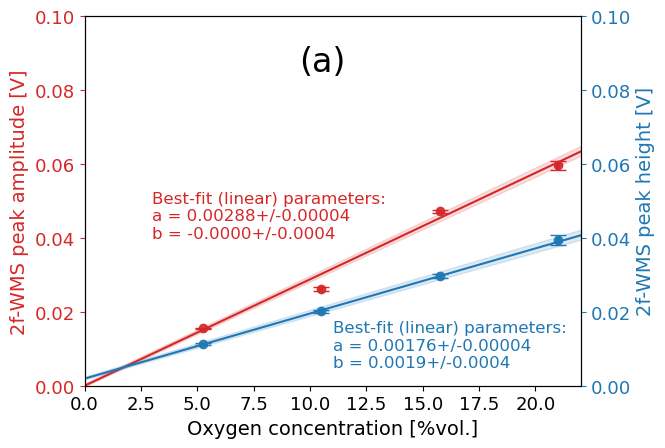

In [25]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Oxygen concentration [%vol.]', fontsize=14)
ax1.set_ylabel('2f-WMS peak amplitude [V]', color=color, fontsize=14)
ax1.tick_params(axis='y', labelcolor=color)

#plt.errorbar(x_data, y_means, y_spread, fmt = 'none', ecolor = 'black')
ax1.errorbar(x_data, A_2f, y_spread, fmt='none', linewidth=3, capsize=6, ecolor = 'tab:red')
# plotting the averaged data with calculated dispersion
ax1.scatter(x_data, A_2f, marker='o', facecolor = 'tab:red', alpha = 0.9)

# plotting the model, 
hires_x = np.linspace(0, 100, 10)
ax1.plot(hires_x, func(hires_x, *best_fit_ab), 'tab:red')
bound_upper = func(hires_x, *(best_fit_ab + sigma_ab))
bound_lower = func(hires_x, *(best_fit_ab - sigma_ab))
# plotting the confidence intervals
ax1.fill_between(hires_x, bound_lower, bound_upper,
                 color = 'tab:red', alpha = 0.15)
ax1.tick_params(axis ='y', which ='major',  
               labelsize = 13, colors ='tab:red')
ax1.tick_params(axis ='x', which ='major', labelsize = 13)

plt.xlim(0, 22)
plt.ylim(0, 0.1)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color2 = 'tab:blue'
ax2.set_ylabel('2f-WMS peak height [V]', color=color2, fontsize=14)  # we already handled the x-label with ax1
ax2.tick_params(axis='y', labelcolor=color2)

#plt.errorbar(x_data, y_means, y_spread, fmt = 'none', ecolor = 'black')
ax2.errorbar(x_data, H_2f, y_spread, fmt='none', linewidth=3, capsize=6, ecolor = 'tab:blue')
# plotting the averaged data with calculated dispersion
ax2.scatter(x_data, H_2f, marker='o', facecolor = 'tab:blue', alpha = 0.9)

# plotting the model
hires_x = np.linspace(0, 100, 10)
ax2.plot(hires_x, func(hires_x, *best_fit_ab2), 'tab:blue')
bound_upper = func(hires_x, *(best_fit_ab2 + sigma_ab2))
bound_lower = func(hires_x, *(best_fit_ab2 - sigma_ab2))
# plotting the confidence intervals
ax2.fill_between(hires_x, bound_lower, bound_upper,
                 color = 'tab:blue', alpha = 0.15)
ax2.tick_params(axis ='y', which ='major',  
               labelsize = 13, colors ='tab:blue')
ax2.tick_params(axis ='x', which ='major', labelsize = 13)

plt.xlim(0, 22)
plt.ylim(0, 0.1)

plt.text(3, 0.04, text_res, color = 'tab:red', fontsize=12)
plt.text(11, 0.005, text_res2, color = 'tab:blue', fontsize=12)
plt.text(9.5, 0.085, "(a)", fontsize=24)


#plt.gcf().set_size_inches(6,6)
plt.savefig("best-fit_unc_A.png", dpi=600, bbox_inches='tight')
plt.savefig("best-fit_unc_A.pdf", dpi=600, bbox_inches='tight')
plt.show()